In [30]:
#pip install pyarrow

In [31]:
#pip install seaborn

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
import pyarrow.feather as feather

def timedelta_from_string(s : str):
     data = s.strip().split(":")
     day = 0
     hourdata =data[0].split(".")
     if(len(data[0]) > 2):
          # Has Day
          day = int(hourdata[0])

     hour = int(hourdata[-1])
     min = int(data[1])
     second = float(data[2])
     return pd.to_timedelta(day,unit = "D") + pd.to_timedelta(hour,unit = "h") + pd.to_timedelta(min,unit = "m") + pd.to_timedelta(second,unit = "s")

stringDT1 = "1.05:25:11.9480000"
stringDT2 = "  10:36:49.9160000"
stringDT3 = "  05:23:28"
stringDT4 = "1.05:23:28"
stringDT5 = "4.00:32:18.5270000"

print(timedelta_from_string(stringDT1))
print(timedelta_from_string(stringDT2))
print(timedelta_from_string(stringDT3))
print(timedelta_from_string(stringDT4))
print(timedelta_from_string(stringDT5))

1 days 05:25:11.948000
0 days 10:36:49.916000
0 days 05:23:28
1 days 05:23:28
4 days 00:32:18.527000


In [33]:
files = ["Res v5.csv","Res v5 p3.csv"]
data = pd.concat([pd.read_csv(f, sep=";", decimal = ",") for f in files], axis=0)

# restrict problems to full probs
problemNames = {x for x in data[data["Algorithm"] == "OSGAstd"]["Problem"].unique()}
data = data[[p in problemNames for p in data["Problem"] ]]

data["time"] = [timedelta_from_string(x) for x in data["time"]]
data["timePerEval"] = data["time"]/data["Evaluations"]
data["Problem"] = [x.replace(".tsv","") for x in data["Problem"]]
problemNames =  np.unique(data["Problem"])

renames = {"algorithmKey": "algorithmKey", "Problem": "dataset", "testR2": "r2_test", "Algorithm": "algorithm"}
data["algorithmKey"] = data["Algorithm"] + ["_depth = "+str(x) for x in data["TreeLength"]]
temp2 = data[["algorithmKey","Algorithm","Problem", "testR2"]].copy()
temp2 = temp2.rename(renames, axis=1)




In [34]:
data

,Algorithm,TreeLength,Problem,testR2,trainingR2,time,Evaluations,Generations,Fold,Rows,Columns,timePerEval,algorithmKey
0,OSGAstd,50,1027_ESL,0.840037,0.902346,0 days 04:51:27.615000,231366,20,0,488,5,0 days 00:00:00.075584204,OSGAstd_depth = 50
1,OSGAstd,50,1027_ESL,0.710296,0.901137,0 days 04:51:27.615000,371966,28,1,488,5,0 days 00:00:00.047014014,OSGAstd_depth = 50
2,OSGAstd,50,1027_ESL,0.901561,0.891726,0 days 04:51:27.615000,191366,19,2,488,5,0 days 00:00:00.091383082,OSGAstd_depth = 50
3,OSGAstd,50,1027_ESL,0.892317,0.897029,0 days 04:51:27.615000,224666,21,3,488,5,0 days 00:00:00.077838279,OSGAstd_depth = 50
4,OSGAstd,50,1027_ESL,0.875022,0.897101,0 days 04:51:27.615000,260666,22,4,488,5,0 days 00:00:00.067088208,OSGAstd_depth = 50
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19105,GAprun,100,712_chscase_geyser1,0.821561,0.878665,0 days 08:09:45.118000,67166,100,5,222,3,0 days 00:00:00.437499895,GAprun_depth = 100
19106,GAprun,100,712_chscase_geyser1,0.813946,0.892826,0 days 08:09:45.118000,67166,100,6,222,3,0 days 00:00:00.437499895,GAprun_depth = 100
19107,GAprun,100,712_chscase_geyser1,0.809842,0.880694,0 days 08:09:45.118000,67166,100,7,222,3,0 days 00:00:00.437499895,GAprun_depth = 100
19108,GAprun,100,712_chscase_geyser1,0.875733,0.890463,0 days 08:09:45.118000,67166,100,8,222,3,0 days 00:00:00.437499895,GAprun_depth = 100


## Read old SRBench results

In [47]:
with open('black-box_results.feather', 'rb') as f:
    read_df = feather.read_feather(f)
print(np.unique(read_df["algorithm"]))
fprobs = np.unique(read_df["dataset"])
print(f"{len([x for x in fprobs if x in problemNames])} of {len(problemNames)} problems")

with open('ground-truth_results.feather', 'rb') as f:
    read_df2 = feather.read_feather(f)
print(np.unique(read_df2["algorithm"]))
fprobs = np.unique(read_df2["dataset"])
oprobs =  np.unique(data["Problem"])
print(f"{len([x for x in fprobs if x in problemNames])} of {len(problemNames)} problems")

srbench = pd.concat([read_df, read_df2])
srbench = srbench[[x ==0 or pd.isna(x) for x in srbench["target_noise"]]]
srbench1 = srbench[[x in problemNames for x in srbench["dataset"]]]
print(
len(srbench["dataset"].unique()),
len(np.unique(srbench["dataset"] + [str(x) for x in srbench["target_noise"]]))
)



['AFP' 'AFP_FE' 'AIFeynman' 'AdaBoost' 'BSR' 'DSR' 'EPLEX' 'FEAT' 'FFX'
 'GP-GOMEA' 'ITEA' 'KernelRidge' 'LGBM' 'Linear' 'MLP' 'MRGP' 'Operon'
 'RandomForest' 'SBP-GP' 'XGB' 'gplearn']
97 of 113 problems
['AFP' 'AFP_FE' 'AIFeynman' 'BSR' 'DSR' 'EPLEX' 'FEAT' 'FFX' 'GP-GOMEA'
 'ITEA' 'MRGP' 'Operon' 'SBP-GP' 'gplearn']
14 of 113 problems
252 252


### Clean Data 

In [36]:
#TODO talk to bogdan ~885 rows have impossible r2 values
srbench1 = srbench1[srbench1["r2_test"]>0]

#TODO talk to bogdan over 2000 different algorithm to parameter combos and even then it is not unique  how do you deal with dupes
paramlookup = {x:str(i) for i,x in enumerate(np.unique([str(e) for e in srbench1["params_str"]]))}
srbench1["paramId"] = [paramlookup[str(e)] for e in srbench1["params_str"]]
srbench1["algorithmKey"] = srbench1["algorithm"] + srbench1["paramId"]

fprobs = np.unique(srbench1["dataset"])
print(len([x for x in fprobs if x in problemNames]), len(problemNames))

111 113


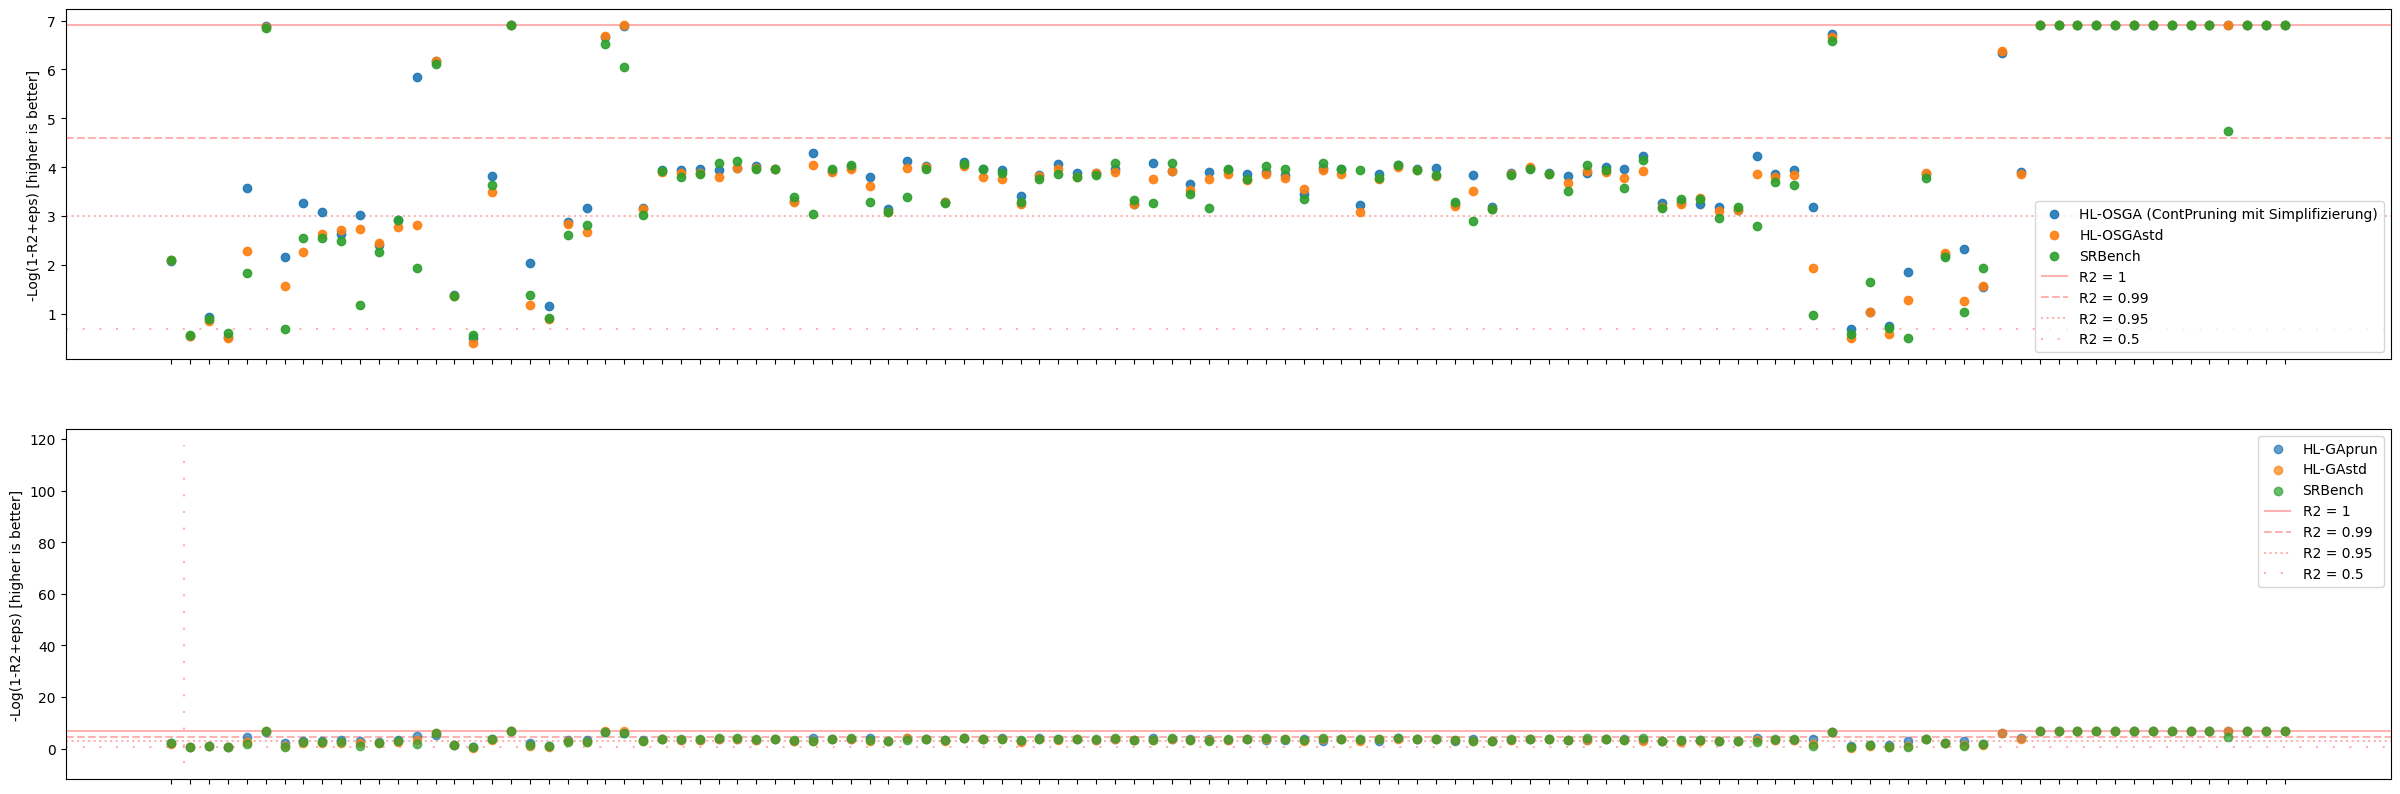

In [37]:
srbenchRes = srbench1[["algorithmKey", "r2_test","dataset","algorithm"]].groupby(["dataset","algorithmKey", "algorithm"]).median().reset_index()
srbenchRes["source"] = "SRBench"

srbenchRes = srbenchRes[srbenchRes["algorithm"] == "Operon"]

hlRes = temp2[["algorithmKey", "r2_test","dataset","algorithm"]].groupby(["dataset","algorithmKey", "algorithm"]).median().reset_index()
hlRes["source"] = "HL-"+ hlRes["algorithm"]
allRes = pd.concat([srbenchRes, hlRes]).reset_index()

bestRes = allRes.loc[allRes.groupby(["dataset", "source",]).idxmax()["r2_test"]]


fig, axs = plt.subplots(2,1,figsize=(30,10), sharex = "col")


ax = axs[0]
lines=[]
names=[]
eps = 0.001 
bestRes["LogR2"] = -np.log(1-bestRes["r2_test"]+eps)

for (k,g) in bestRes.groupby("source"):
    if "HL-GA" in k:
        continue
    lines.append(ax.scatter(g["dataset"], g["LogR2"], alpha=0.9, zorder=1))
    names.append(k)

ax.set_xticklabels([])
ax.set_ylabel("-Log(1-R2+eps) [higher is better]")
xlim = ax.get_xlim()
lines.append(ax.hlines(-np.log(eps), xlim[0], xlim[1], colors= "red", alpha = 0.3, zorder=0))
names.append("R2 = 1")
lines.append(ax.hlines(-np.log(0.01), xlim[0], xlim[1], colors= "red",alpha = 0.3,linestyles="dashed", zorder=0))
names.append("R2 = 0.99")
lines.append(ax.hlines(-np.log(0.05), xlim[0], xlim[1], colors= "red",alpha = 0.3,linestyles="dotted", zorder=0))
names.append("R2 = 0.95")
lines.append(ax.hlines(-np.log(0.5), xlim[0], xlim[1], colors= "red", alpha = 0.3,linestyles=(0, (1, 7)), zorder=0))
names.append("R2 = 0.5")
ax.set_xlim(xlim)
ax.legend(lines, names)


ax = axs[1]
lines=[]
names=[]

for (k,g) in bestRes.groupby("source"):
    if "HL-OSGA" in k:
        continue
    lines.append(ax.scatter(g["dataset"], g["LogR2"], alpha=0.7, zorder=1))
    names.append(k)
ax.set_xticklabels([])
ax.set_ylabel("-Log(1-R2+eps) [higher is better]")
xlim = ax.get_xlim()
lines.append(ax.hlines(-np.log(eps), xlim[0], xlim[1], colors= "red", alpha = 0.3, zorder=0))
names.append("R2 = 1")
lines.append(ax.hlines(-np.log(0.01), xlim[0], xlim[1], colors= "red",alpha = 0.3,linestyles="dashed", zorder=0))
names.append("R2 = 0.99")
lines.append(ax.hlines(-np.log(0.05), xlim[0], xlim[1], colors= "red",alpha = 0.3,linestyles="dotted", zorder=0))
names.append("R2 = 0.95")
lines.append(ax.hlines(-np.log(0.5), xlim[0], xlim[1], colors= "red", alpha = 0.3,linestyles=(0, (1, 7)), zorder=0))
lines.append(ax.vlines(-np.log(0.5), xlim[0], xlim[1], colors= "red", alpha = 0.3,linestyles=(0, (1, 7)), zorder=0))
names.append("R2 = 0.5")
ax.set_xlim(xlim)
ax.legend(lines, names)
plt.show()

## Pruning vs Non-Pruning

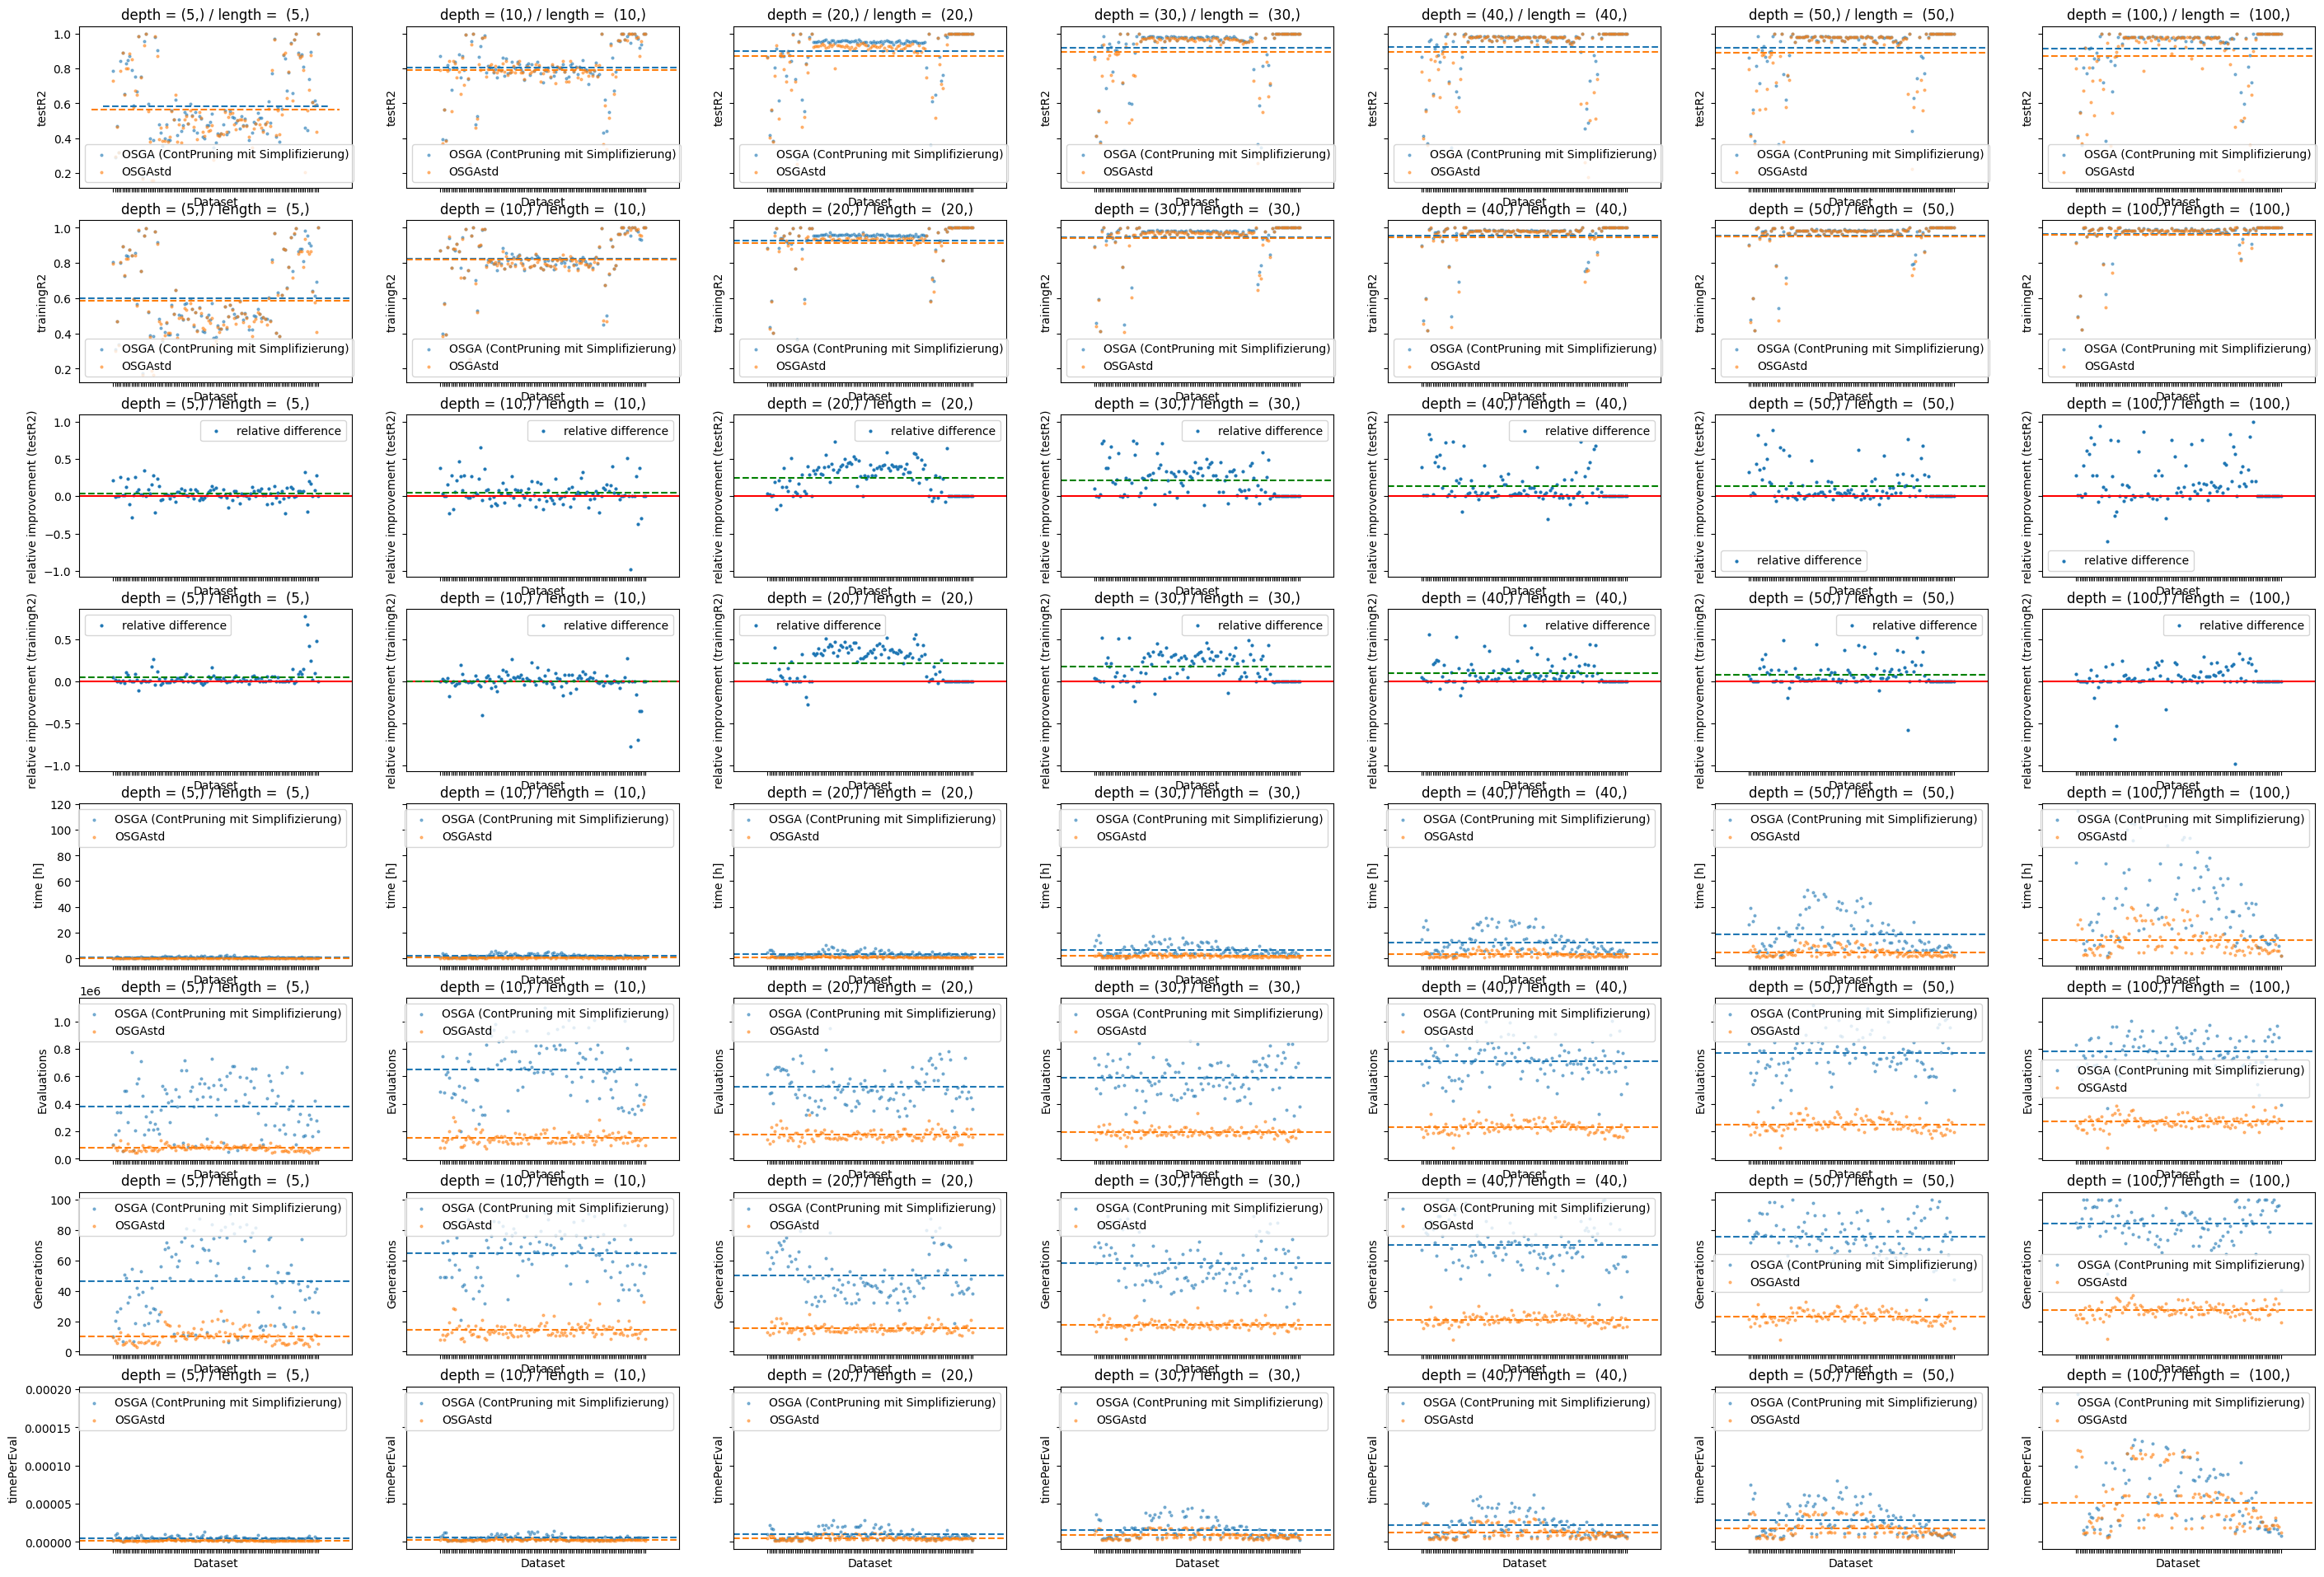

In [64]:
def plot_comparison(df, target = "testR2", title="", ax = None, algs = ["OSGA (ContPruning mit Simplifizierung)", "OSGAstd"],) :
    global test
    df_pivot = df\
        .drop(["Fold"],axis = 1)\
        .groupby(["algorithmKey","Algorithm", "Problem", "Rows", "Columns"])\
        .mean()\
        .reset_index()\
        .pivot(
            index=["Problem", "Rows", "Columns"], 
            columns=["Algorithm"], 
            values= [target])\
        .reset_index()
    if ax == None:
        fig,ax = plt.subplots(1,1,figsize=(15,2))
    lineA =[]
    hour = pd.Timedelta(hours=1)
    for alg in algs:
        ya = df_pivot[target][alg]
        if target == "time" or target == "timePerEval":
            ya = [x/hour for x in ya]
        test = ax.scatter(df_pivot["Problem"], ya, alpha=0.5,s = 4, color = f'C{len(lineA)}')
        lineA = lineA + [test]
        xlim = ax.get_xlim()
        ax.hlines(np.mean(ya), xlim[0], xlim[1], colors= f'C{len(lineA)-1}', linestyles="dashed")
    ax.tick_params(axis='x',labelrotation=90, labelbottom=False)
    ax.legend(labels=algs, handles=lineA)
    ax.set_ylabel(target if target!="time" else target+ " [h]")
    ax.set_title(title)
    xlim = ax.get_xlim()
    #ax.hlines(0, xlim[0], xlim[1], colors= "red")
    #ax.hlines(np.mean(ya), xlim[0], xlim[1], colors= "green", linestyles="dashed")
    ax.set_xlim(xlim)
    ax.set_xlabel("Dataset")

def plot_comparison_diff(df, target = "testR2", title="", ax = None, algs = ["OSGA (ContPruning mit Simplifizierung)", "OSGAstd"]) :
    df_pivot = df\
        .drop(["Fold"],axis = 1)\
        .groupby(["algorithmKey","Algorithm", "Problem", "Rows", "Columns"])\
        .mean()\
        .reset_index()\
        .pivot(
            index=["Problem", "Rows", "Columns"], 
            columns=["Algorithm"], 
            values= [target])\
        .reset_index()
    if ax == None:
        fig,ax = plt.subplots(1,1,figsize=(15,2))
    lineA =[]
    hour = pd.Timedelta(hours=1)
    ya = [(a-b)/(1-min(a,b)) if min(a,b)<0.99 else (a-b) for (a,b) in zip(df_pivot[target][algs[0]],df_pivot[target][algs[1]])]
    if target == "time":
        ya = [x/hour for x in ya]
    lineA = lineA + [ax.scatter(df_pivot["Problem"], ya,s = 4)]
    ax.tick_params(axis='x',labelrotation=90, labelbottom=False)
    ax.legend(labels=["relative difference"], handles=lineA)
    ax.set_ylabel("relative improvement ("+(target if target!="time" else target+ " [h]")+")")
    ax.set_title(title)
    xlim = ax.get_xlim()
    ax.hlines(0, xlim[0], xlim[1], colors= "red")
    ax.hlines(np.mean(ya), xlim[0], xlim[1], colors= "green", linestyles="dashed")
    ax.set_xlim(xlim)
    ax.set_xlabel("Dataset")


algs = ["OSGA (ContPruning mit Simplifizierung)", "OSGAstd"]
groups = [(f'depth = {x[0]} / length =  {x[0]}', x[1]) for x in data[[x in algs for x in data["Algorithm"]]].groupby(["TreeLength"], as_index=False)]
targets = ["testR2", "trainingR2","testR2", "trainingR2", "time", "Evaluations", "Generations", "timePerEval"]
reldiff = [False, False, True, True,False, False,False, False]
fig, axs = plt.subplots(len(targets),len(groups),figsize=(5*len(groups),3*len(targets)), sharey="row", sharex="all")

for i, target in enumerate(targets):
    for j,(name, df) in enumerate(groups):
        if reldiff[i]:
            plot_comparison_diff(df, target, name, axs[i][j], algs=algs)
        else:
            plot_comparison(df, target, name, axs[i][j], algs=algs)

In [39]:
test

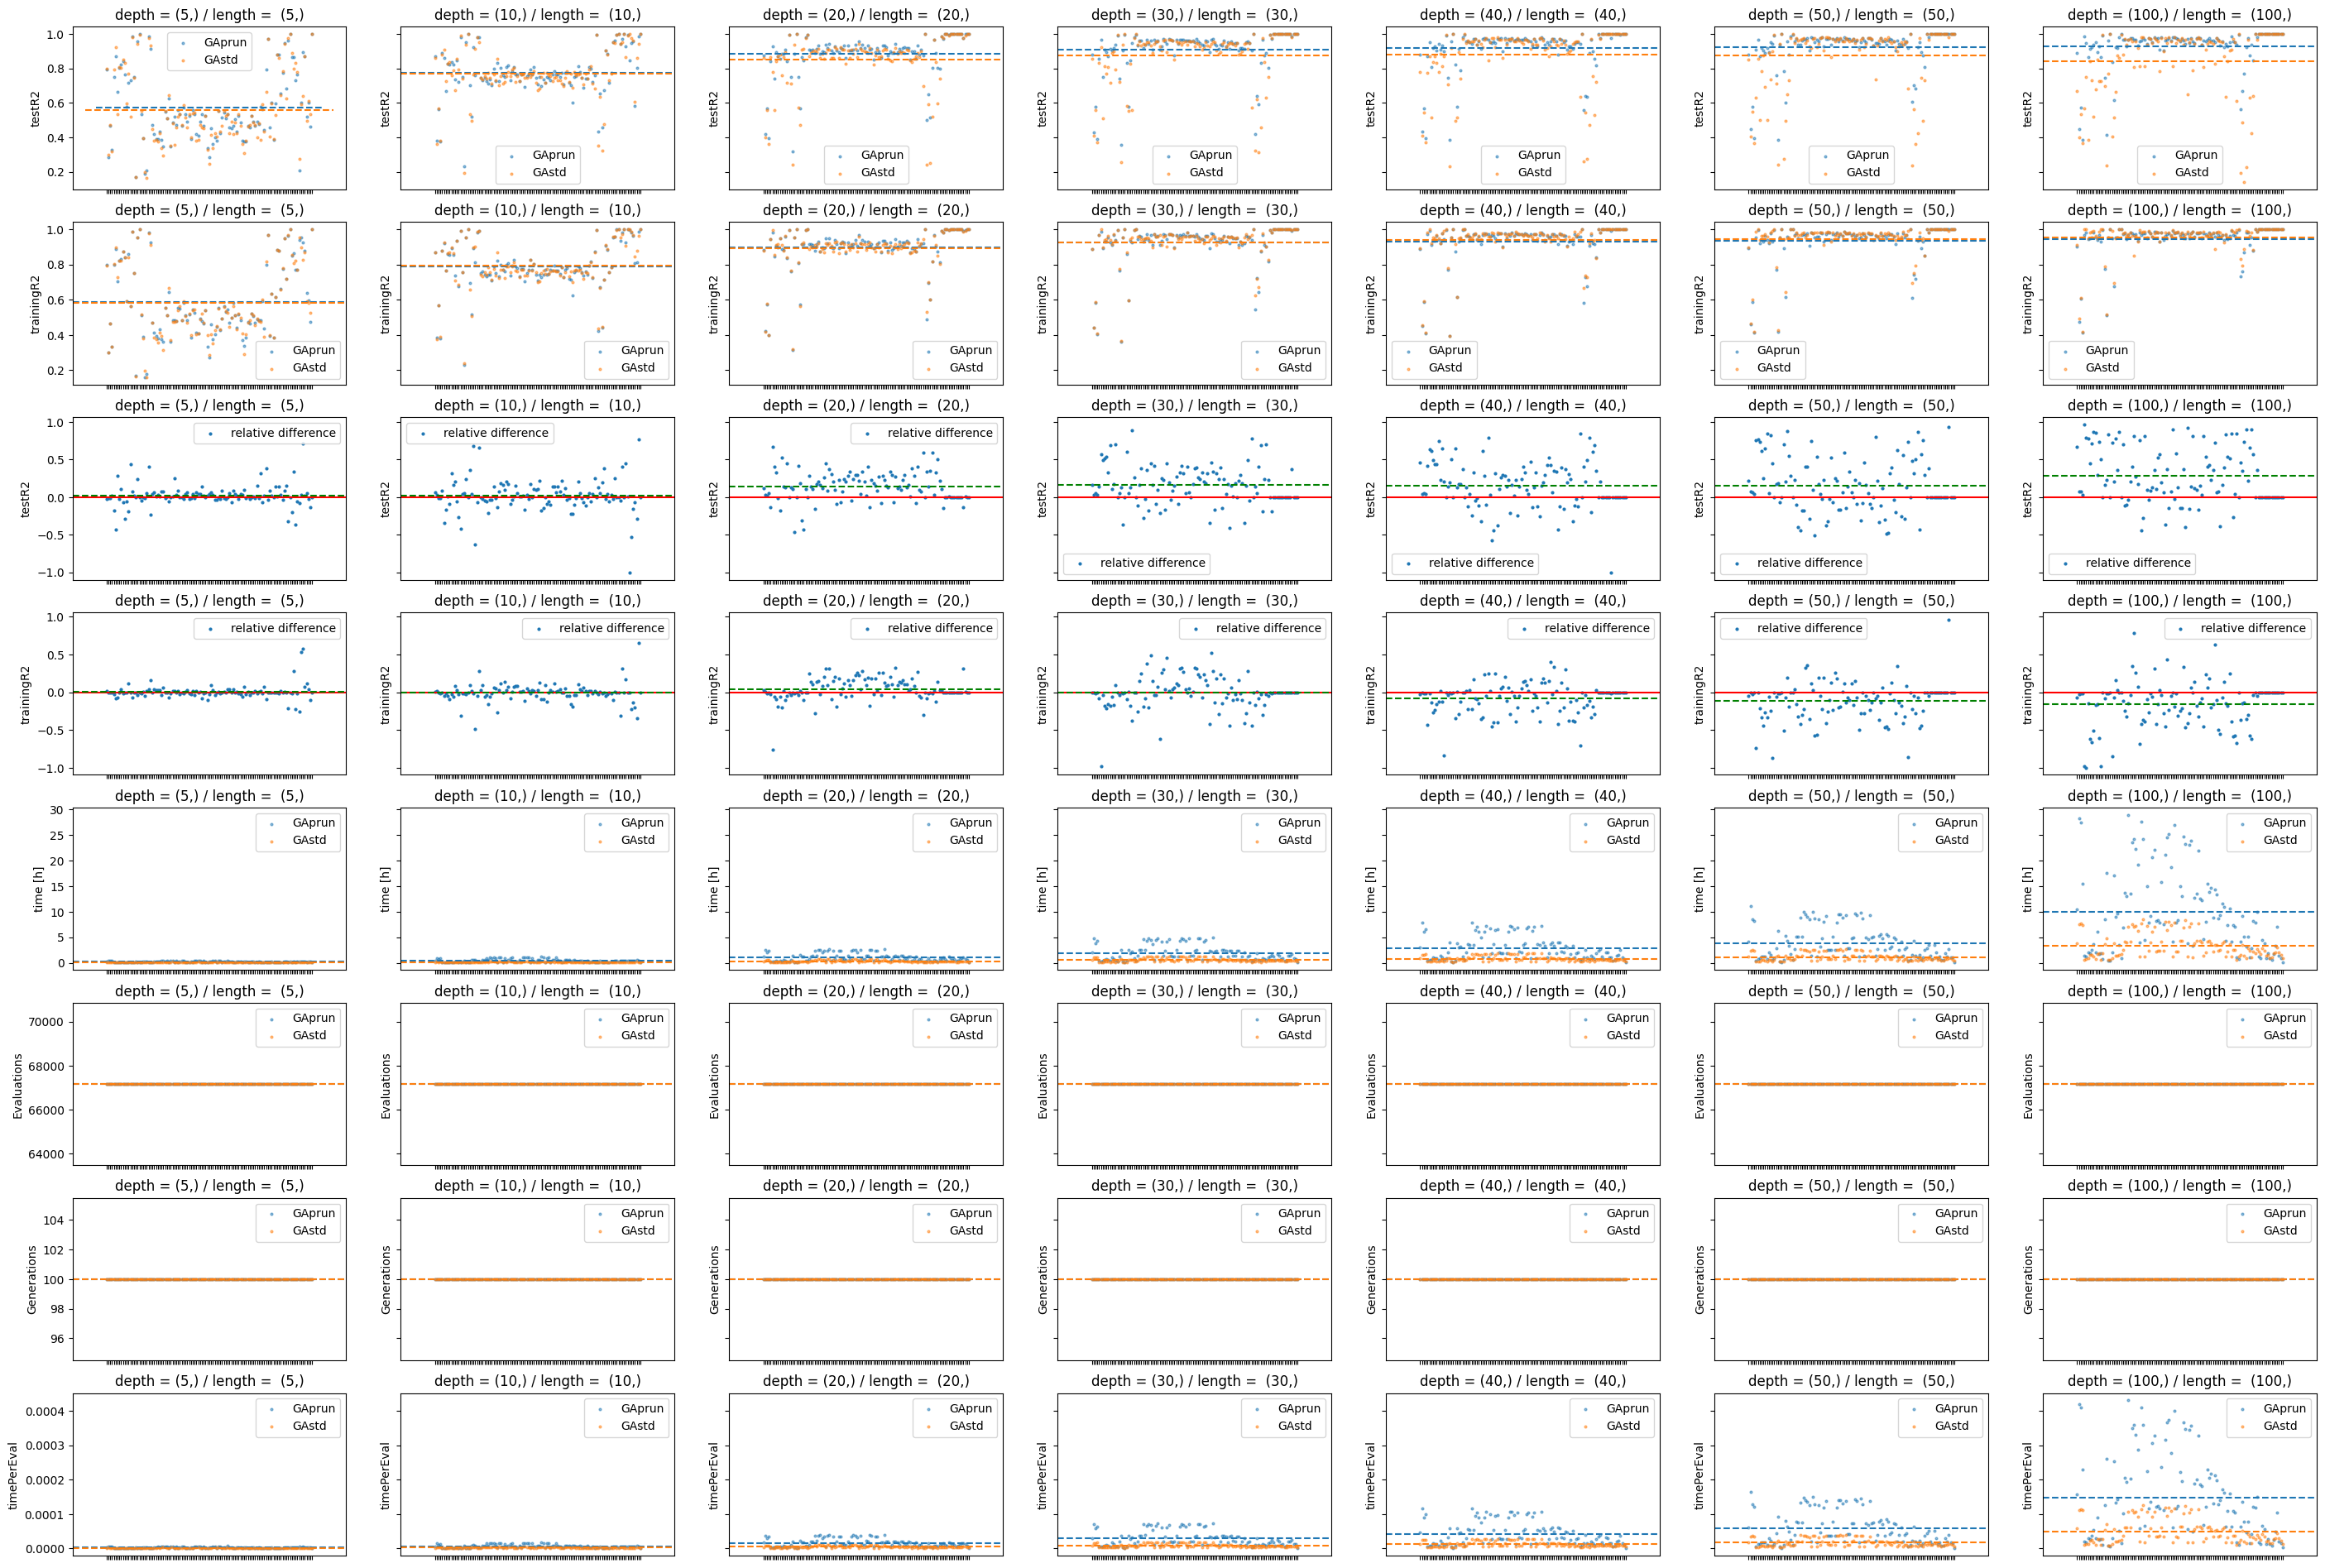

In [40]:
algs = ['GAprun', 'GAstd']
#algs = ["OSGA (ContPruning mit Simplifizierung)", "OSGAstd"]
groups = [(f'depth = {x[0]} / length =  {x[0]}', x[1]) for x in data[[x in algs for x in data["Algorithm"]]].groupby(["TreeLength"], as_index=False)]
targets = ["testR2", "trainingR2","testR2", "trainingR2", "time", "Evaluations", "Generations", "timePerEval"]
reldiff = [False, False, True, True,False, False,False, False]
fig, axs = plt.subplots(len(targets),len(groups),figsize=(5*len(groups),3*len(targets)), sharey="row", sharex="all")

for i, target in enumerate(targets):
    for j,(name, df) in enumerate(groups):
        if reldiff[i]:
            plot_comparison_diff(df, target, name, axs[i][j], algs=algs)
        else:
            plot_comparison(df, target, name, axs[i][j], algs=algs)

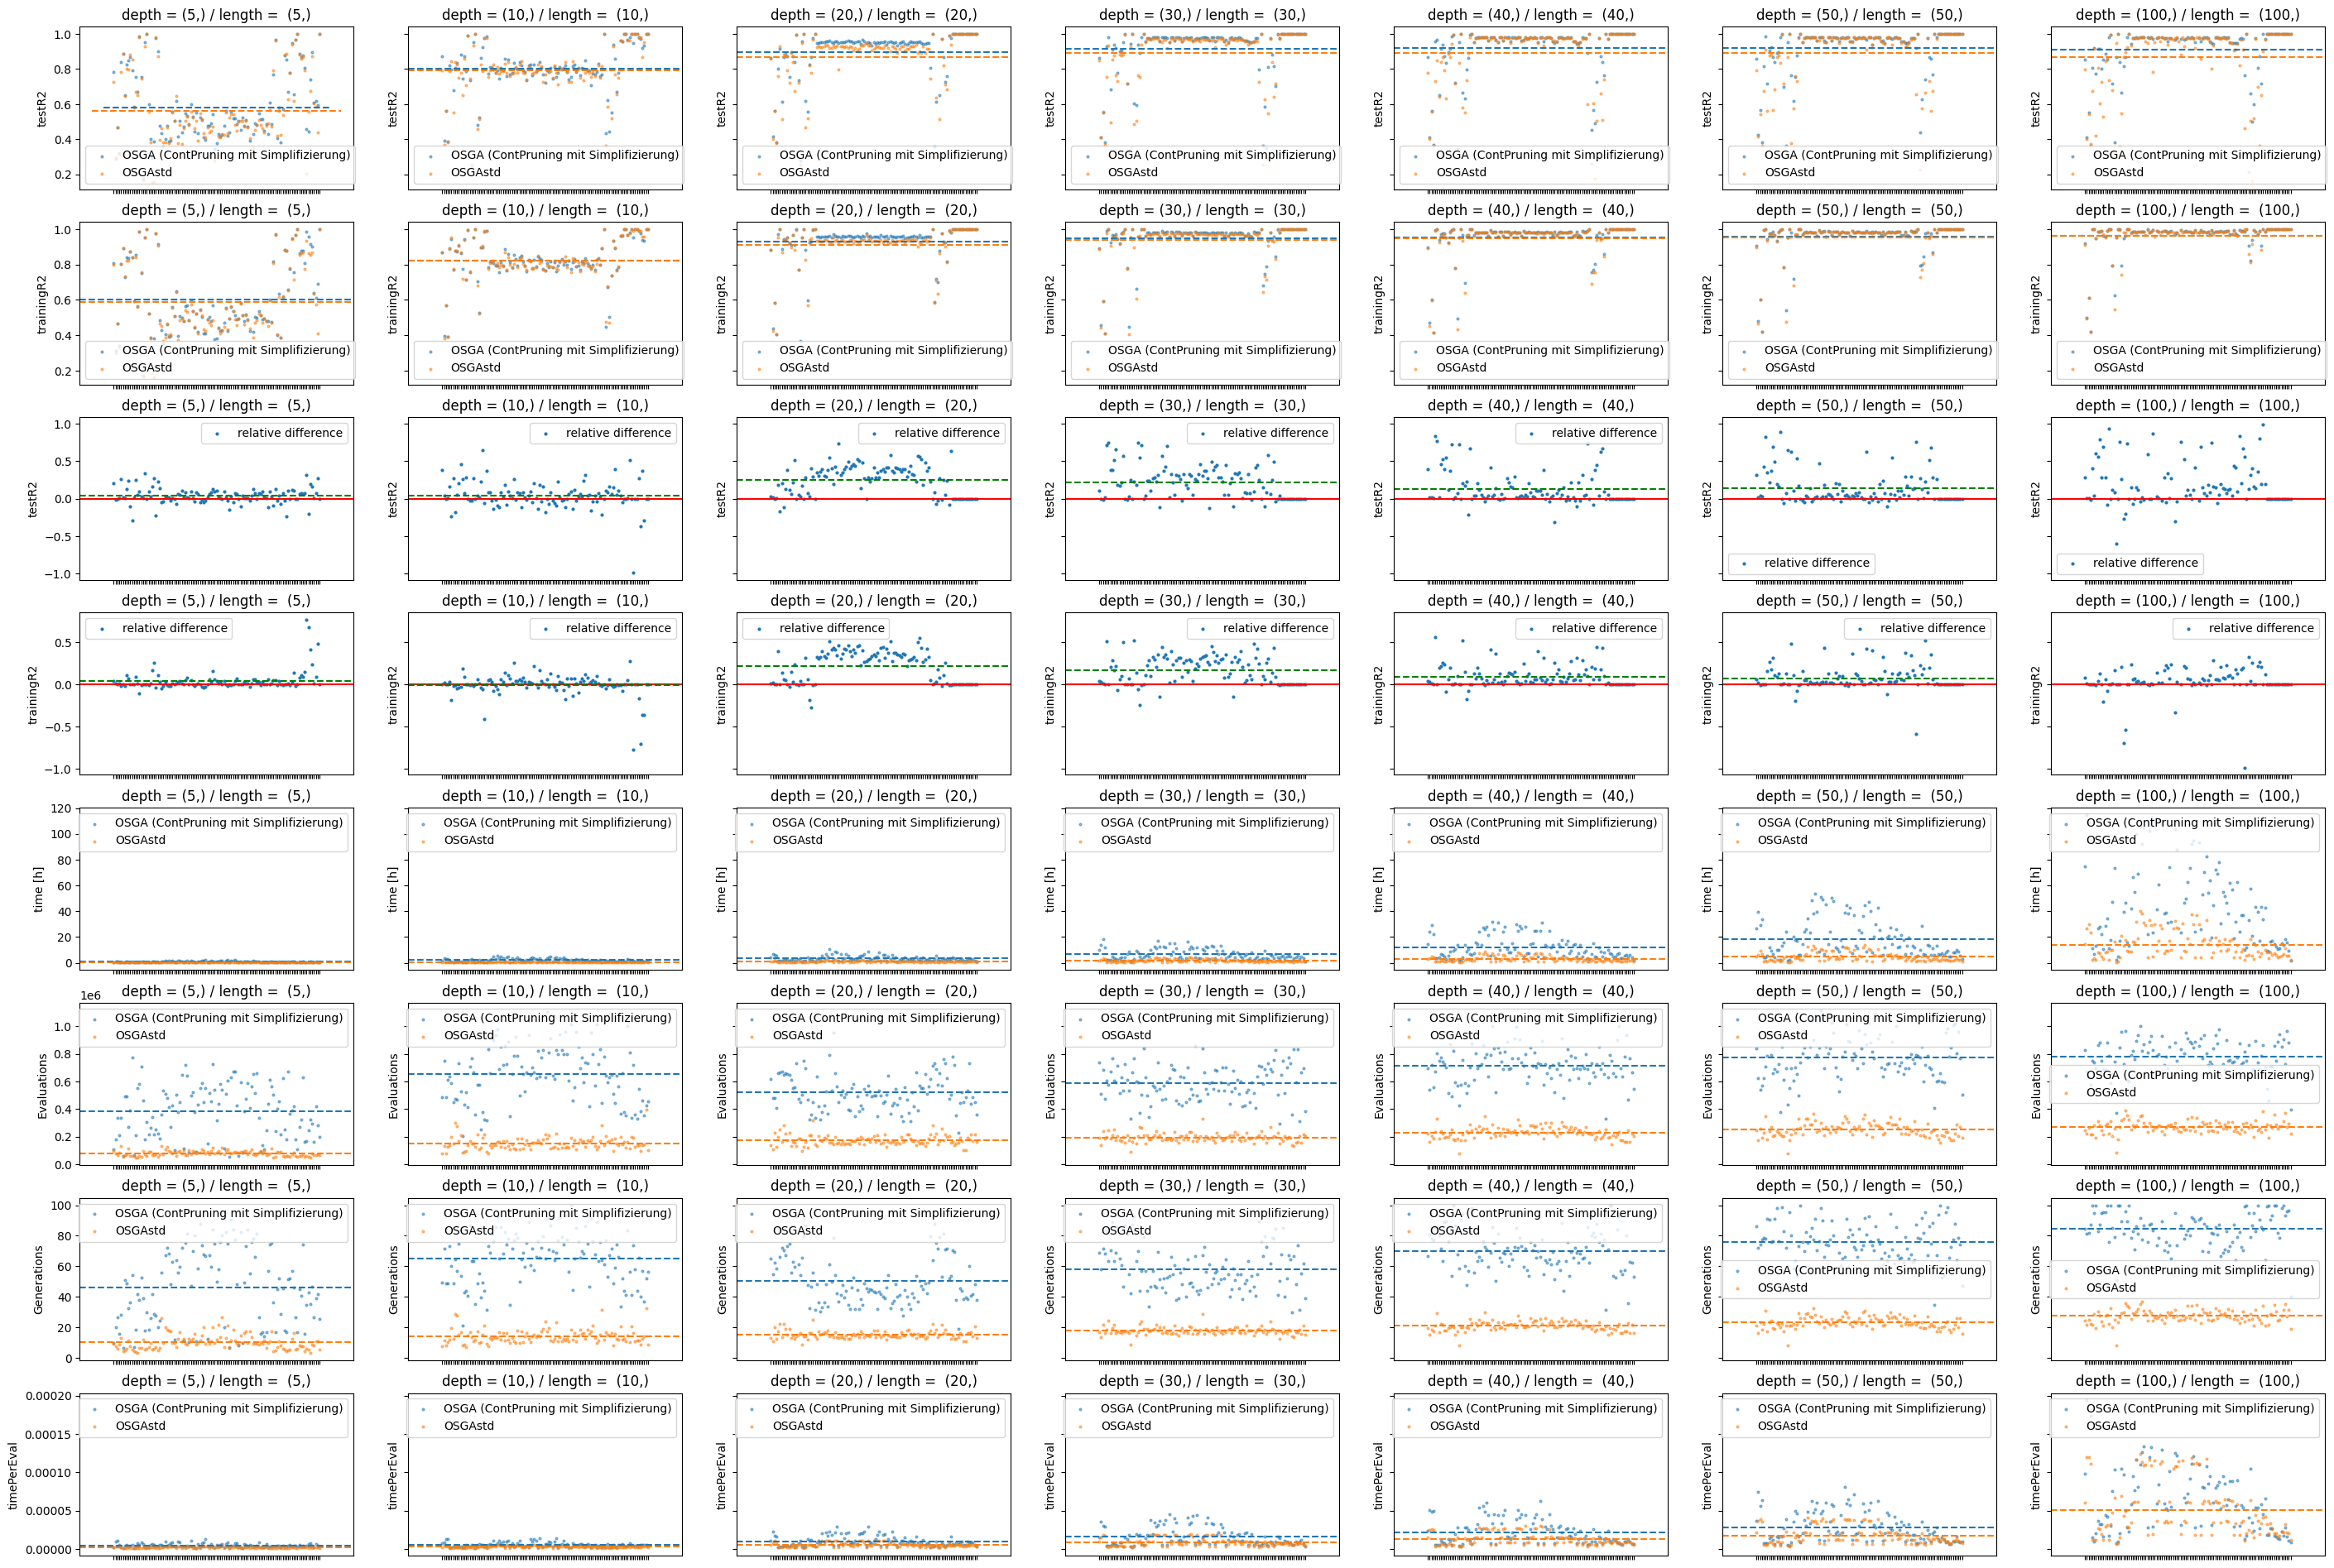

In [56]:
algs = ["OSGA (ContPruning mit Simplifizierung)", "OSGAstd"]
groups = [(f'depth = {x[0]} / length =  {x[0]}', x[1]) for x in data[[x in algs for x in data["Algorithm"]]].groupby(["TreeLength"], as_index=False)]
targets = ["testR2", "trainingR2","testR2", "trainingR2", "time", "Evaluations", "Generations", "timePerEval"]
reldiff = [False, False, True, True,False, False,False, False]
fig, axs = plt.subplots(len(targets),len(groups),figsize=(5*len(groups),3*len(targets)), sharey="row", sharex="all")

for i, target in enumerate(targets):
    for j,(name, df) in enumerate(groups):
        if reldiff[i]:
            plot_comparison_diff(df, target, name, axs[i][j], algs=algs)
        else:
            plot_comparison(df, target, name, axs[i][j], algs=algs)

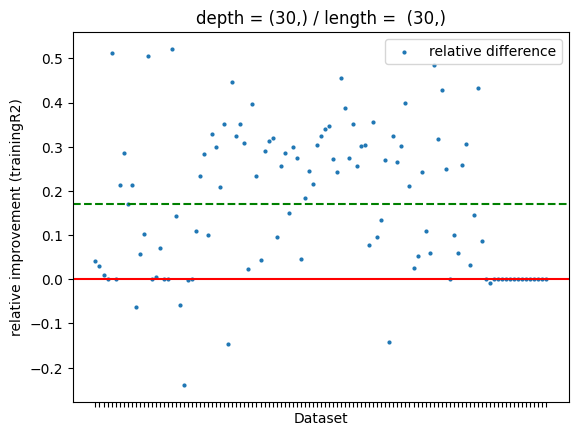

In [65]:
fig,ax = plt.subplots(1,1)
plot_comparison_diff(groups[3][1], "trainingR2", groups[3][0], ax, algs=["OSGA (ContPruning mit Simplifizierung)", "OSGAstd"])

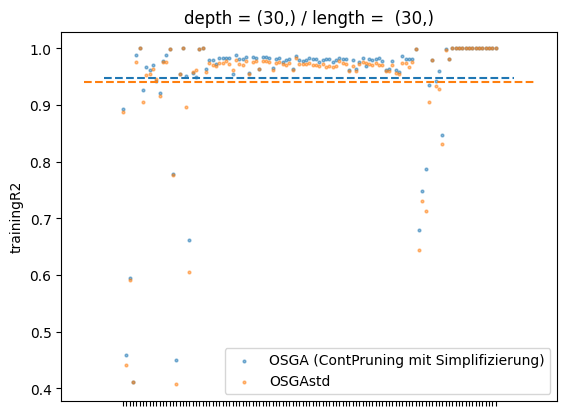

In [61]:
axfig,ax = plt.subplots(1,1)
plot_comparison(groups[3][1], "trainingR2", groups[3][0], ax, algs=["OSGA (ContPruning mit Simplifizierung)", "OSGAstd"])